In [3]:
import Bio
import itertools
import random
from Bio import SeqIO

import pandas as pd
from Bio.Restriction import AllEnzymes

from Bio.Restriction.Restriction_Dictionary import rest_dict
import numpy as np
import re
from Bio.Seq import Seq
import pandas as pd

In [62]:
def sticky_end_to_fidelity(sticky_end1, sticky_end2, df_fidelity=None):
    """Calculate fidelity between two sticky ends using the fidelity DataFrame.
    
    Args:
        sticky_end1: First sticky end sequence
        sticky_end2: Second sticky end sequence
        df_fidelity: Pre-loaded fidelity DataFrame (optional)
    
    Returns:
        Sum of fidelity values between the ends and their reverse complements
    """
    # Use provided DataFrame or load if not provided
    if df_fidelity is None:
        fidelity_file = '../utils/input/golden_gate_fidelity/FileS03_T4_18h_25C.xlsx'
        df_fidelity = pd.read_excel(fidelity_file)
        df_fidelity.index = df_fidelity['Overhang']
    
    # Create reverse complements
    sticky_end1_rc = str(Seq(sticky_end1).reverse_complement())
    sticky_end2_rc = str(Seq(sticky_end2).reverse_complement())
    
    # Initialize fidelity values
    fidelity_values = []
    
    # Define pairs to check
    pairs_to_check = [
        (sticky_end1, sticky_end1),
        (sticky_end2, sticky_end2),
        (sticky_end1_rc, sticky_end1_rc),
        (sticky_end2_rc, sticky_end2_rc),
        (sticky_end1, sticky_end2),
        (sticky_end1, sticky_end2_rc),
        (sticky_end1_rc, sticky_end2),
        (sticky_end1_rc, sticky_end2_rc)
    ]
    
    # Check each pair and handle errors
    for seq1, seq2 in pairs_to_check:
        try:
            value = df_fidelity.loc[seq1, seq2]
            fidelity_values.append(value)
            #print(f"Fidelity for {seq1} and {seq2}: {value}")
        except KeyError:
            print(f"Warning: Could not find fidelity for {seq1} and {seq2}")
            fidelity_values.append(0)  # or another default value
    
    fidelity_value = sum(fidelity_values)
    #print(f"Total fidelity: {fidelity_value}")
    
    return fidelity_value

In [76]:
fidelity_file = '../utils/input/golden_gate_fidelity/FileS03_T4_18h_25C.xlsx'
df_fidelity = pd.read_excel(fidelity_file)
df_fidelity.index = df_fidelity['Overhang']

In [77]:
nucleotides = ['A', 'T', 'G', 'C']
sticky_end = [''.join(seq) for seq in itertools.product(nucleotides, repeat=4)]


sticky_end_df = pd.DataFrame(itertools.product(sticky_end, sticky_end), columns=['sticky_end1', 'sticky_end2'])
sticky_end_df['fidelity_value'] = sticky_end_df.apply(lambda row: sticky_end_to_fidelity(row['sticky_end1'], row['sticky_end2'], df_fidelity=df_fidelity), axis=1)


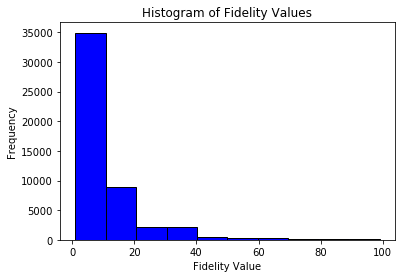

In [78]:
import matplotlib.pyplot as plt

sticky_end_df_sele = sticky_end_df[(sticky_end_df['fidelity_value'] < 100) & (sticky_end_df['fidelity_value'] > 0)]

plt.hist(sticky_end_df_sele['fidelity_value'], color='blue', edgecolor='black')
plt.title('Histogram of Fidelity Values')
plt.xlabel('Fidelity Value')
plt.ylabel('Frequency')
plt.show()

In [105]:
def get_orthogonality(row, df_fidelity=None):
    """
    Calculate the orthogonality between two restriction enzymes based on their sticky ends.

    Description of return values:
    - 4: Overhangs (ovhg) are different.
    - 3: Orthogonal sticky ends.
    - 2: Mederately orthogonal sticky ends.
    - 1: Weakly orthogonal sticky ends or short sticky ends.
    - 0: Same sticky end or compatible sticky ends.

    Args:
        row: A row from a DataFrame containing restriction enzyme information.
        df_fidelity: Pre-loaded fidelity DataFrame (optional).

    Returns:
        An integer representing the orthogonality level.
    """
    # Use provided DataFrame or load if not provided
    if df_fidelity is None:
        fidelity_file = '../utils/input/golden_gate_fidelity/FileS03_T4_18h_25C.xlsx'
        df_fidelity = pd.read_excel(fidelity_file)
        df_fidelity.index = df_fidelity['Overhang']

    re1 = row['re1']
    re2 = row['re2']

    ovhg1 = getattr(Bio.Restriction, re1).ovhg
    ovhg2 = getattr(Bio.Restriction, re2).ovhg

    ovhgseq1 = getattr(Bio.Restriction, re1).ovhgseq
    ovhgseq2 = getattr(Bio.Restriction, re2).ovhgseq

    if ovhg1 != ovhg2:
        return 4

    if ovhgseq1 == ovhgseq2 or ovhgseq1 == Seq(ovhgseq2).reverse_complement():
        return 0

    if abs(ovhg1) in [0,1,2,3]:
        return 1

    fidelity = sticky_end_to_fidelity(ovhgseq1, ovhgseq2, df_fidelity=df_fidelity)

    if fidelity <= 10:
        return 3
    elif fidelity <= 40:
        return 2
    else:
        return 1

In [112]:
df_re_list = pd.read_csv('../utils/output/restriction_enzyme.csv')
re_list = df_re_list['name'].unique().tolist()

In [113]:
fidelity_file = '../utils/input/golden_gate_fidelity/FileS03_T4_18h_25C.xlsx'
df_fidelity = pd.read_excel(fidelity_file)
df_fidelity.index = df_fidelity['Overhang']

In [114]:
df = pd.DataFrame(itertools.product(re_list, re_list), columns=['re1', 're2'])

df['orthogonality'] = df.apply(get_orthogonality, axis=1, df_fidelity=df_fidelity)


In [115]:
df

,re1,re2,orthogonality
0,EcoRI,EcoRI,0
1,EcoRI,BauI,1
2,EcoRI,TaiI,4
3,EcoRI,AatII,4
4,EcoRI,HindIII,1
...,...,...,...
4895,AflII,ApaLI,1
4896,AflII,EcoT22I,4
4897,AflII,SdaI,4
4898,AflII,PstI,4


In [117]:
df.to_csv('../utils/output/orthogonality.csv', index=False)